<a href="https://colab.research.google.com/github/GermanAlmanza14/Econometria_con_Python/blob/main/WAGE1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


### License: Creative Commons Attribution 4.0 International (CC BY 4.0)
This work is licensed under a [Creative Commons Attribution 4.0 International License](https://creativecommons.org/licenses/by/4.0/).
<br>
© 2025 Germán Almanza ralmanza@uacj.mx


# **Ejemplo 2.4 de Wooldridge: Salario - Educación**

**wage1.raw:**<br>
Datos de 1976, Obs:526. Buscamos la regresión
$$salario=\beta_0+\beta_1 educ+u$$

Fórmula para actualizar el salario
$$Salario*\frac{IPC_{final}}{IPC_{inicial}}$$


In [ ]:
!pip install wooldridge

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 29.9 MB/s eta 0:00:00


In [ ]:
import wooldridge as woo
import numpy as np

wage1=woo.dataWoo('wage1' )
wage1

salario=wage1['wage']
edu=wage1['educ']

In [ ]:
#   Salario promedio 1976
sal_prm=np.mean(salario)
sal_prm
print('El salario promedio de la muestra (1976) es:',f'{sal_prm:.2f}')

El salario promedio de la muestra (1976) es: 5.90


## **Salario y tasa de inflación: *Sticky Wage Theory***

Con el **IPC** (indice de precios al consumidor) podemos calcular el nivel de inflación de la siguiente manera:

$$\%Inflación=\frac{IPC_{Actual}-IPC_{Anterior}}{IPC_{Anterior}}\times 100$$


De la fórmula anterior deducimos la equivalencia del salario anterior en valor actual
$$Salario_E=\frac{IPC_{Actual}}{IPC_{Anterior}}\times Salario_{Anterior}$$

Los salarios en la muestra son en dolares de US y el IPC de US lo encontramos en [US inflation calculator](https://www.usinflationcalculator.com/inflation/consumer-price-index-and-annual-percent-changes-from-1913-to-2008/#google_vignette).


In [ ]:
# julio
IPC_2025=321.943
IPC_2003=184
IPC_2016=240.007
IPC_1976=56.9

sal_25=sal_prm*IPC_2025/IPC_1976
print('El salario promedio de 1976, en 2025 equivale a:',f'{sal_25:.2f}')

#sal_E03=sal_prm*IPC_2003/IPC_1976
#print('El salario promedio de 1976 equivale a:',f'{sal_E03:.2f}')
#print('El salario promedio de 1976 equivale a:',sal_E03)


El salario promedio de 1976, en 2025 equivale a: 33.36


In [ ]:
sal_p16=sal_prm*IPC_2016/IPC_1976
sal_p16

np.float64(24.870051224386856)

In [ ]:
sal_p25=sal_prm*IPC_2025/IPC_1976
sal_p25

np.float64(33.36043907608018)

La ecuación de estimación OLS es
$$\widehat{salario}=\widehat{\beta_0}+\widehat{\beta_1}*edu$$

recordemos que los estimadores estan definidos por
$$\hat\beta_0=\bar y - \hat\beta_1\bar x\quad\text{y}\quad\beta_1=\frac{cov(x,y)}{var(x)}$$


In [ ]:
edu_prm=np.mean(edu)
Var_e=np.var(edu,ddof=1)  # ddof=1 var muestral
#Var_e_0=np.var(edu,ddof=0)
Cov_ew=np.cov(edu,salario)[0,1]  # sin [0,1] muestra la matriz var-cov

print('Varianza (muestral) de educación  var(edu)=',f'{Var_e:.2f}')
#print('Varianza de educación  var(edu)=',f'{Var_e_0:.2f}')

print('Promedio de Educación:',f'{edu_prm:.2f}')
print('Covarianza Educación-Salario:',f'{Cov_ew:.2f}')

Varianza (muestral) de educación  var(edu)= 7.67
Promedio de Educación: 12.56
Covarianza Educación-Salario: 4.15


In [ ]:
Beta1_ew=Cov_ew/Var_e
Beta0_ew=sal_prm-Beta1_ew*edu_prm

print('Estimadores Beta0:',f'{Beta0_ew:.2f}' ' y Beta1: '  f'{Beta1_ew:.2f}')

Estimadores Beta0: -0.90 y Beta1: 0.54


#  La regresion queda como
$$\widehat{salario}=-0.904+0.541*edu$$

# **Observa: -Modo Experto- completa la siguiente tabla, con las variables arriba descritas.**

In [ ]:
import pandas as pd
from IPython.display import display, Markdown

statics=[r'$\bar y$',r'$\bar x$',r'$\hat \beta_0$',r'$\hat \beta_1$',
         'recta de ajuste']
values=[f'{sal_prm:.2f}',f'{edu_prm:.2f}',f'{Beta0_ew:.3f}',
        f'{Beta1_ew:.3f}',
        f'salario={Beta0_ew:.3f}+{Beta1_ew:.3f}*edu']
tabla0=pd.DataFrame({'estadisticos':statics,'valores':values})
tabla0

# Display DataFrame with LaTeX
display(Markdown(tabla0.to_markdown()))




|    | estadisticos    | valores                  |
|---:|:----------------|:-------------------------|
|  0 | $\bar y$        | 5.90                     |
|  1 | $\bar x$        | 12.56                    |
|  2 | $\hat \beta_0$  | -0.905                   |
|  3 | $\hat \beta_1$  | 0.541                    |
|  4 | recta de ajuste | salario=-0.905+0.541*edu |

#  La regresion queda como
$$\widehat{salario}=-0.904+0.541*edu$$

## **Función de tendencia (predicción)**

Muestra la tendencia del **salario**, para ciertos $x$ años de **educación**.

In [ ]:
Beta0_ew=round(Beta0_ew,2)
Beta1_ew=round(Beta1_ew,2)

def wage(x):
    return Beta0_ew+Beta1_ew*x
educ=12.56


we=wage(educ)
print('Con', f'{educ}', 'años de educación, la función estima un salario de:'
,f'${we:.4f}' )

Con 12.56 años de educación, la función estima un salario de: $5.8824


In [ ]:
edu10=wage(10)
edu15=wage(15)

De la regresión anterior se tiene que el salario promedio de una persona
con 8 años de educación es de $3.42 por hora. De modo que,
ese salario con el IPC del 2025 esquivale a

In [ ]:
wage_25=we*IPC_2025/IPC_1976
print('En dolares del 2025 son:', f'${wage_25:.2f}')

En dolares del 2025 son: $33.28


# **Ejemplo: 2.7 Salario y Educación**

In [ ]:
import wooldridge as woo
import statsmodels.formula.api as stf

reg_wage1=stf.ols('wage~educ',data=wage1).fit()
reg_wage1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   wage   R-squared:                       0.165
Model:                            OLS   Adj. R-squared:                  0.163
Method:                 Least Squares   F-statistic:                     103.4
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           2.78e-22
Time:                        18:24:54   Log-Likelihood:                -1385.7
No. Observations:                 526   AIC:                             2775.
Df Residuals:                     524   BIC:                             2784.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.9049      0.685     -1.321      0.187      -2.250       0.441
educ           0.5414      0.053     10.167      0.000       0.437       0.646
==============================================================================
Omnibus:                      212.554   Durbin-Watson:                   1.824
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              807.843
Skew:                           1.861   Prob(JB):                    3.79e-176
Kurtosis:                       7.797   Cond. No.                         60.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

De la regresión lineal anterior deducimos la ecuación

$$\widehat{wage}=-0.9049+0.5414*educ,$$
donde $\hat\beta_0=-0.9049$ y $\hat\beta_1=5414$.

* Por definición de salario, el estimador $\hat\beta_0$ no tiene interpretación económica, ya que esta ecuación afirma que un trabajador con cero años de educación tendría un salario de $ \$-0.90$,
* Por otra parte, $\hat\beta_1=.5414$ (la pendiente de la recta) la interpretamos como el incremento del salario, por cada año de educación que incrementa el empleado.

/tmp/ipykernel_7671/802765805.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Beta0_ew=betas[0]
/tmp/ipykernel_7671/802765805.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Beta1_ew=betas[1]


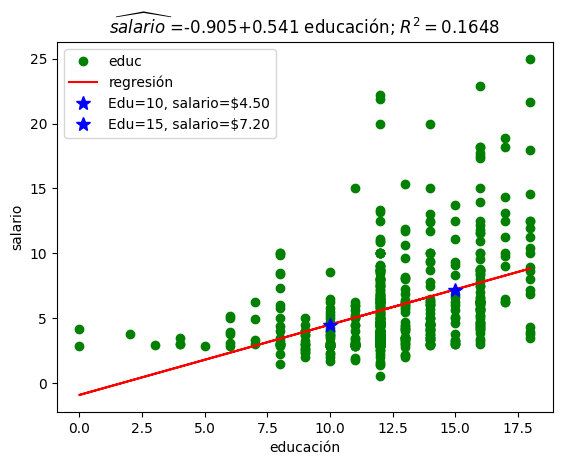

In [ ]:
import matplotlib.pyplot as plt

betas=reg_wage1.params

Beta0_ew=betas[0]
Beta1_ew=betas[1]

Rsqrt=reg_wage1.rsquared


#plt.figure(figsize=(10,6))
plt.plot('educ','wage',data=wage1,color='g',marker='o',linestyle='',label='educ')
plt.plot(wage1['educ'],reg_wage1.fittedvalues,color='red',linestyle='-',label='regresión')
plt.ylabel ('salario')
plt.xlabel ('educación')
#   estimaciones realizadas/sugeridas
plt.plot(10,edu10,color='b',marker='*',linestyle='',label=f'Edu=10, salario=${edu10:.2f}',  markersize=10)
plt.plot(15,edu15,color='b',marker='*',linestyle='',label=f'Edu=15, salario=${edu15:.2f}',  markersize=10)

#   titulo
plt.title(r'$\widehat{salario}$ ='+'{:.3f}'.format(Beta0_ew)+ '+{:.3f}'.format(Beta1_ew)+' educación;' r' $R^2=$''{:.4f}'.format(Rsqrt), size=12)
plt.legend()
plt.savefig('Reg_wage1.jpg')
plt.show()

# **Forma funcional no lineal (log)**

## 2.4 Wooldridge

In [ ]:
import wooldridge as woo
import numpy as np
import statsmodels.formula.api as stf

reg_lwage1=stf.ols('np.log(wage)~educ',data=wage1).fit()
reg_lwage1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           np.log(wage)   R-squared:                       0.186
Model:                            OLS   Adj. R-squared:                  0.184
Method:                 Least Squares   F-statistic:                     119.6
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           3.27e-25
Time:                        18:24:55   Log-Likelihood:                -359.38
No. Observations:                 526   AIC:                             722.8
Df Residuals:                     524   BIC:                             731.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.5838      0.097      5.998      0.000       0.393       0.775
educ           0.0827      0.008     10.935      0.000       0.068       0.098
==============================================================================
Omnibus:                       11.804   Durbin-Watson:                   1.801
Prob(Omnibus):                  0.003   Jarque-Bera (JB):               13.811
Skew:                           0.268   Prob(JB):                      0.00100
Kurtosis:                       3.586   Cond. No.                         60.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Al aplicar $\log$ a la variable dependiente, los resultados obviamente cambian y también su interpretación. Tenemos la ecuación de regresión

$$\widehat{log(wage)}=0.5838+0.0827*edu;\quad R^2=0.186$$
Los estimadores:

* $\hat\beta_0=0.5838$ es el intercepto que como la anterior regresión (lineal) no tiene un significado económico.

* $\hat\beta_1=0.0827$ nos dice que por cada año de educación del empleado el ingreso incrementa en poco más de $8.2\%$



/tmp/ipykernel_7671/3045150792.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lbeta0=lbetas[0]
/tmp/ipykernel_7671/3045150792.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lbeta1=lbetas[1]


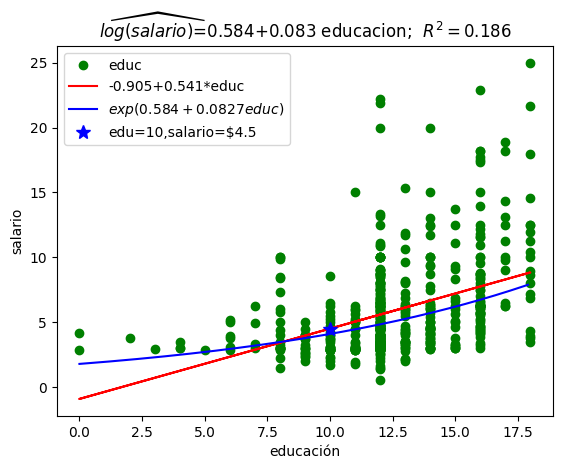

In [ ]:
import matplotlib.pyplot as plt

lbetas=reg_lwage1.params
lRsqrt=reg_lwage1.rsquared
lbeta0=lbetas[0]
lbeta1=lbetas[1]

x=np.arange(0, 18, 0.1)
y=np.exp(lbeta0+lbeta1*x)
#plt.figure(figsize=(10,6))
plt.plot('educ','wage',data=wage1,color='g',marker='o',linestyle='',label='educ')
plt.plot(wage1['educ'],reg_wage1.fittedvalues,color='red',linestyle='-',label=f'{Beta0_ew:.3}+{Beta1_ew:.3}*educ')
plt.plot(x,y,color='blue',label=f'$exp({lbeta0:.3}+{lbeta1:.3}educ)$')
plt.ylabel ('salario')
plt.xlabel ('educación')
plt.plot(10,edu10,color='b',marker='*',linestyle='',label=f'edu=10,salario=${edu10:.2}',  markersize=10)

#   titulo
plt.title(r'$\widehat{log(salario)}$' f'={lbeta0:.3f}+{lbeta1:.3f} educacion; ' fr' $R^2=${lRsqrt:.3f}', size=12)
plt.legend()
plt.savefig('Reg_wage2.jpg')
plt.show()